# Aircraft Orders and Deliveries Forecasting Analysis - Airbus

## Project Overview

This project investigates global aircraft demand trends using Airbus commercial aviation datasets.

The analysis focuses on:
- Aircraft orders
- Aircraft deliveries
- Backlog growth
- Market demand trends
- Aircraft family popularity
- Time-series forecasting

The long-term goal is to build predictive forecasting models capable of estimating future aircraft demand and delivery trends using statistical and machine learning techniques.

---

## Objectives

- Clean and standardise Airbus datasets
- Perform exploratory data analysis
- Analyse historical aviation demand trends
- Build forecasting models for aircraft deliveries and orders
- Visualise long-term aviation market dynamics

---

## Tools and Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Statsmodels
- Scikit-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid") #sets plotting style

#Define data folder path
file_path = os.path.expanduser(
    "~/Desktop/Airbus Orders and Deliveries Forecasting/Data"
)

aircraft_data = pd.read_excel(
    f"{file_path}/aircraft_data.xlsx"
)

#Displays first rows
aircraft_data.head()

/Users/zeabayunus/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/Users/zeabayunus/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:79: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


,ICAO_Code,FAA_Designator,Manufacturer,Model_FAA,Model_BADA,Physical_Class_Engine,Num_Engines,AAC,AAC_minimum,AAC_maximum,...,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55
0,A10,A10,FAIRCHILD,Fairchild A10,Fairchild A-10A,Jet,2,C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A124,A124,ANTONOV,Antonov AN-124 Ruslan,Antonov AN-124-100,Jet,4,D,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A19N,A19N,AIRBUS,Airbus A319 Neo,Airbus A319 Neo,Jet,2,C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A20N,A20N,AIRBUS,Airbus A320 Neo,Airbus A320-271N,Jet,2,C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A21N,A21N,AIRBUS,Airbus A321 Neo,Airbus A321-251N,Jet,2,C,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
aircraft_data.shape #Checks dataset dimensions

(388, 56)

In [8]:
aircraft_data.columns #Displays column names

Index(['ICAO_Code', 'FAA_Designator', 'Manufacturer', 'Model_FAA',
       'Model_BADA', 'Physical_Class_Engine', 'Num_Engines', 'AAC',
       'AAC_minimum', 'AAC_maximum', 'ADG', 'TDG', 'Approach_Speed_knot',
       'Approach_Speed_minimum_knot', 'Approach_Speed_maximum_knot',
       'Wingspan_ft_without_winglets_sharklets',
       'Wingspan_ft_with_winglets_sharklets', 'Length_ft',
       'Tail_Height_at_OEW_ft', 'Wheelbase_ft', 'Cockpit_to_Main_Gear_ft',
       'Main_Gear_Width_ft', 'MTOW_lb', 'MALW_lb', 'Main_Gear_Config',
       'ICAO_WTC', 'Parking_Area_ft2', 'Class', 'FAA_Weight', 'CWT',
       'One_Half_Wake_Category', 'Two_Wake_Category_Appx_A',
       'Two_Wake_Category_Appx_B', 'Rotor_Diameter_ft', 'SRS', 'LAHSO',
       'FAA_Registry', 'Registration_Count', 'TMFS_Operations_FY24', 'Remarks',
       'LastUpdate', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43',
       'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47',
       'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', '

In [9]:
aircraft_data.isnull().sum() #Checks for missing values

ICAO_Code                                   0
FAA_Designator                              0
Manufacturer                                0
Model_FAA                                   0
Model_BADA                                  2
Physical_Class_Engine                       0
Num_Engines                                 0
AAC                                         3
AAC_minimum                               376
AAC_maximum                               376
ADG                                         0
TDG                                         0
Approach_Speed_knot                         3
Approach_Speed_minimum_knot               377
Approach_Speed_maximum_knot               377
Wingspan_ft_without_winglets_sharklets     20
Wingspan_ft_with_winglets_sharklets       356
Length_ft                                   0
Tail_Height_at_OEW_ft                       0
Wheelbase_ft                                0
Cockpit_to_Main_Gear_ft                     0
Main_Gear_Width_ft                

## Data Cleaning and Preprocessing

The aircraft dataset contains 388 aircraft types and 56 variables related to aircraft dimensions, operational performance, wake turbulence category, engine configuration, and airport compatibility metrics.

Initial exploratory analysis identified several issues:
- Multiple unnamed columns containing entirely missing values
- Columns with excessive null values
- Operational metrics requiring type conversion and cleaning
- Potentially irrelevant variables for forecasting analysis

The preprocessing stage focuses on removing unusable variables, handling missing data, and preparing the dataset for statistical analysis and predictive modelling.

In [10]:
#remove completely empty columns
aircraft_data = aircraft_data.dropna(axis=1, how="all")

#check updated dataset shape
aircraft_data.shape

(388, 42)

In [11]:
#display remaining missing values

aircraft_data.isnull().sum().sort_values(ascending=False)

Unnamed: 55                               387
Rotor_Diameter_ft                         387
Approach_Speed_maximum_knot               377
Approach_Speed_minimum_knot               377
AAC_minimum                               376
AAC_maximum                               376
LastUpdate                                374
Wingspan_ft_with_winglets_sharklets       356
Remarks                                   258
LAHSO                                      67
MALW_lb                                    21
Wingspan_ft_without_winglets_sharklets     20
AAC                                         3
Two_Wake_Category_Appx_A                    3
Approach_Speed_knot                         3
Two_Wake_Category_Appx_B                    3
Model_BADA                                  2
Registration_Count                          1
SRS                                         0
TMFS_Operations_FY24                        0
Parking_Area_ft2                            0
FAA_Registry                      

In [12]:
#display cleaned column names

aircraft_data.columns

Index(['ICAO_Code', 'FAA_Designator', 'Manufacturer', 'Model_FAA',
       'Model_BADA', 'Physical_Class_Engine', 'Num_Engines', 'AAC',
       'AAC_minimum', 'AAC_maximum', 'ADG', 'TDG', 'Approach_Speed_knot',
       'Approach_Speed_minimum_knot', 'Approach_Speed_maximum_knot',
       'Wingspan_ft_without_winglets_sharklets',
       'Wingspan_ft_with_winglets_sharklets', 'Length_ft',
       'Tail_Height_at_OEW_ft', 'Wheelbase_ft', 'Cockpit_to_Main_Gear_ft',
       'Main_Gear_Width_ft', 'MTOW_lb', 'MALW_lb', 'Main_Gear_Config',
       'ICAO_WTC', 'Parking_Area_ft2', 'Class', 'FAA_Weight', 'CWT',
       'One_Half_Wake_Category', 'Two_Wake_Category_Appx_A',
       'Two_Wake_Category_Appx_B', 'Rotor_Diameter_ft', 'SRS', 'LAHSO',
       'FAA_Registry', 'Registration_Count', 'TMFS_Operations_FY24', 'Remarks',
       'LastUpdate', 'Unnamed: 55'],
      dtype='object')

In [13]:
#remove columns with excessive missing values

columns_to_drop = [
    "Unnamed: 55",
    "Rotor_Diameter_ft",
    "AAC_minimum",
    "AAC_maximum",
    "Approach_Speed_minimum_knot",
    "Approach_Speed_maximum_knot",
    "LastUpdate"
]

aircraft_data = aircraft_data.drop(columns=columns_to_drop)

#check updated dataset shape

aircraft_data.shape

(388, 35)

In [14]:
#final check of missing values
aircraft_data.isnull().sum().sort_values(ascending=False)

Wingspan_ft_with_winglets_sharklets       356
Remarks                                   258
LAHSO                                      67
MALW_lb                                    21
Wingspan_ft_without_winglets_sharklets     20
AAC                                         3
Two_Wake_Category_Appx_B                    3
Two_Wake_Category_Appx_A                    3
Approach_Speed_knot                         3
Model_BADA                                  2
Registration_Count                          1
FAA_Registry                                0
SRS                                         0
ICAO_WTC                                    0
TMFS_Operations_FY24                        0
One_Half_Wake_Category                      0
CWT                                         0
FAA_Weight                                  0
Class                                       0
Parking_Area_ft2                            0
ICAO_Code                                   0
Main_Gear_Config                  

## Descriptive Statistics

Following preprocessing, descriptive statistical analysis was performed to better understand the distribution of key aircraft characteristics within the dataset.

This stage provides insight into:
- aircraft size variation,
- operational weight distributions,
- fleet composition,
- and engineering characteristics across different aircraft types.

Understanding these distributions is important before conducting forecasting and predictive modelling.

In [15]:
#summary statistics for numerical variables

aircraft_data.describe()

,Num_Engines,Approach_Speed_knot,Wingspan_ft_without_winglets_sharklets,Wingspan_ft_with_winglets_sharklets,Length_ft,Tail_Height_at_OEW_ft,Wheelbase_ft,Cockpit_to_Main_Gear_ft,Main_Gear_Width_ft,MTOW_lb,MALW_lb,Parking_Area_ft2,LAHSO,Registration_Count,TMFS_Operations_FY24
count,388.000000,385.000000,368.000000,32.000000,388.000000,388.000000,388.000000,388.000000,388.000000,3.880000e+02,367.000000,388.00000,321.000000,387.000000,3.880000e+02
mean,1.904639,105.709091,72.435054,108.257500,73.777861,22.068660,28.833582,30.663918,17.040593,1.037196e+05,82477.980926,9388.33634,5.227414,470.289406,7.879570e+04
std,0.837542,30.416356,49.996959,37.059646,57.623194,15.680739,23.915834,27.123789,9.536783,2.003630e+05,150216.454616,13232.60901,2.628212,1483.283495,2.300740e+05
min,1.000000,39.000000,24.400000,52.200000,19.300000,5.900000,3.200000,1.800000,5.300000,1.220000e+03,1220.000000,834.60000,1.000000,0.000000,0.000000e+00
25%,1.000000,79.000000,37.275000,91.710000,29.500000,9.975000,10.575000,10.500000,10.500000,5.066500e+03,4406.500000,1717.52500,3.000000,25.000000,4.600000e+02
50%,2.000000,108.000000,50.300000,105.850000,49.850000,15.400000,20.650000,20.950000,14.000000,1.704300e+04,15675.000000,3321.50000,6.000000,121.000000,8.001000e+03
75%,2.000000,130.000000,92.100000,117.500000,99.500000,28.300000,38.100000,41.950000,20.400000,9.340000e+04,82600.000000,10938.32500,7.000000,415.000000,5.063100e+04
max,8.000000,192.000000,261.700000,212.430000,251.800000,79.000000,107.900000,121.600000,47.400000,1.267658e+06,868621.000000,66179.40000,10.000000,20154.000000,2.484764e+06


## Aircraft Manufacturer Distribution

The global commercial aviation industry is highly concentrated among a relatively small number of manufacturers.

This section evaluates:
- manufacturer representation,
- aircraft family concentration,
- and relative market dominance within the dataset.

Understanding manufacturer concentration is important when analysing aircraft demand, fleet planning, and long-term delivery forecasting.

In [16]:
#count aircraft by manufacturer

manufacturer_counts = (
    aircraft_data["Manufacturer"]
    .value_counts()
    .reset_index()
)

manufacturer_counts.columns = [
    "Manufacturer",
    "Aircraft_Count"
]

#display results

manufacturer_counts.head(15)

,Manufacturer,Aircraft_Count
0,CESSNA,53
1,BOEING,41
2,PIPER,31
3,BEECH,27
4,AIRBUS,23
5,EMBRAER,17
6,LEARJET,11
7,BOEING-MCDONNELL DOUGLAS,11
8,GULFSTREAM AEROSPACE,9
9,ATR,8


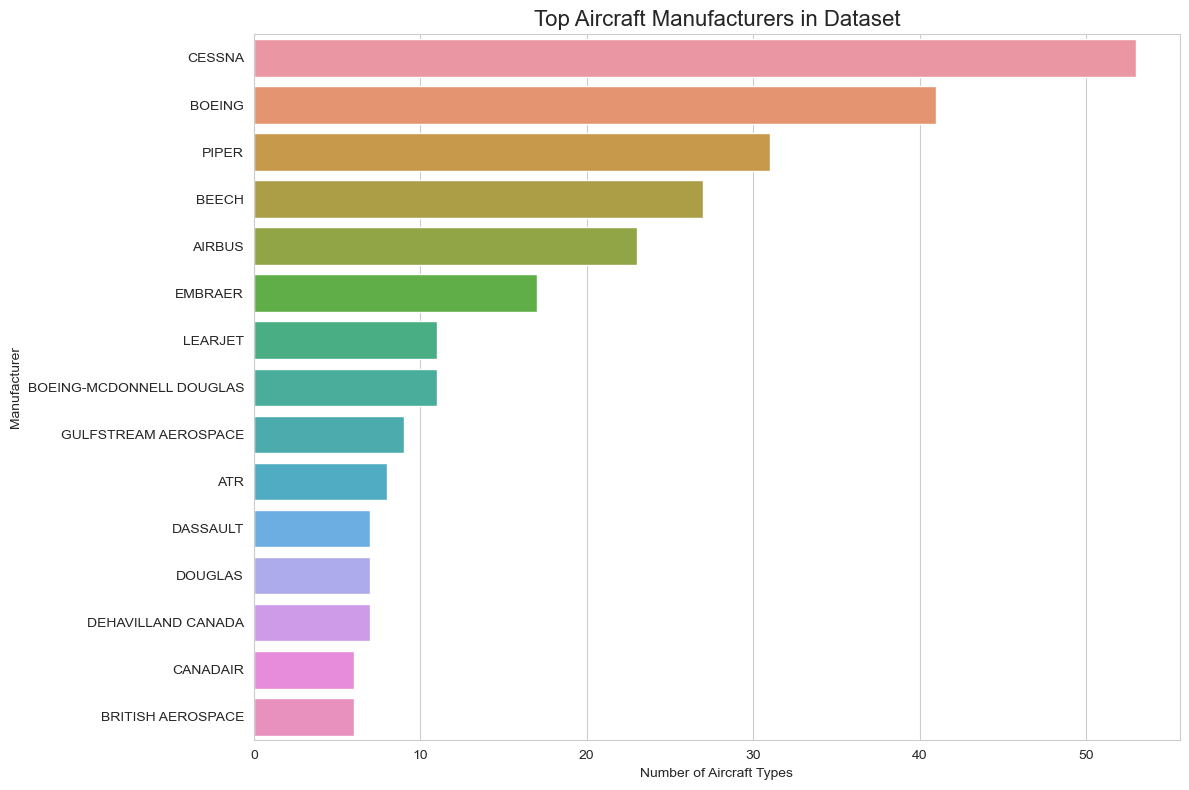

In [17]:
#visualise manufacturer distribution

plt.figure(figsize=(12,8))

sns.barplot(
    data=manufacturer_counts.head(15),
    x="Aircraft_Count",
    y="Manufacturer"
)

plt.title(
    "Top Aircraft Manufacturers in Dataset",
    fontsize=16
)

plt.xlabel("Number of Aircraft Types")
plt.ylabel("Manufacturer")

plt.tight_layout()



plt.savefig(
    os.path.expanduser(
        "~/Desktop/Airbus Orders and Deliveries Forecasting/Visuals/manufacturer_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation of Aircraft Manufacturer Distribution

- The manufacturer distribution demonstrates a highly concentrated aerospace industry, with a relatively small number of firms accounting for the majority of aircraft types within the dataset.


- CESSNA represents the largest manufacturer category in the dataset. This reflects the large number of light aircraft, training aircraft, and smaller utility aircraft produced by the company over several decades.


- BOEING and AIRBUS both feature prominently, highlighting their dominant position within the global commercial aviation market. Although Airbus has fewer aircraft families represented compared to Boeing, Airbus aircraft account for a substantial proportion of modern commercial airline operations worldwide.


- The strong representation of BOEING reflects the company’s extensive historical production range, including legacy McDonnell Douglas aircraft following the merger between the two manufacturers.


- Regional and business jet manufacturers such as EMBRAER, LEARJET, ATR, and GULFSTREAM AEROSPACE also appear frequently within the dataset. This indicates the importance of regional connectivity and corporate aviation within the wider aerospace industry.


- Manufacturers such as PIPER and BEECH are heavily represented due to their historical role in producing general aviation aircraft, training aircraft, and smaller utility platforms.


- The dataset contains evidence of market segmentation within aviation manufacturing:
    
    - Airbus and Boeing dominate large commercial aviation,
    - Embraer and ATR focus primarily on regional aviation,
    - while firms such as Gulfstream and Learjet specialise in business aviation.


- The presence of legacy manufacturers such as DOUGLAS and BRITISH AEROSPACE highlights the historical evolution of the aerospace industry through mergers, acquisitions, and consolidation.


- The distribution suggests that aircraft manufacturing is characterised by high barriers to entry, where only a limited number of firms are capable of operating at global commercial scale.


- Manufacturer concentration has important implications for:
    
    - airline fleet planning,
    - supply chain resilience,
    - aircraft delivery forecasting,
    - and exposure to production disruptions.


- The dominance of a few major manufacturers also means that global aviation demand forecasts are highly sensitive to production rates and operational performance at a relatively small number of aerospace firms.

## Aircraft Weight and Size Correlation Analysis

Aircraft operational performance is strongly influenced by physical dimensions and structural weight characteristics.

This section investigates relationships between:
- maximum take-off weight (MTOW),
- aircraft length,
- wingspan,
- and parking area requirements.

Correlation analysis is important because larger aircraft generally require:
- greater airport infrastructure,
- longer runways,
- wider taxiways,
- and higher operational costs.

Understanding these relationships provides insight into aircraft scaling behaviour and airport capacity requirements.

In [18]:
#key numerical variables

numerical_variables = aircraft_data[
    [
        "MTOW_lb",
        "Length_ft",
        "Wingspan_ft_without_winglets_sharklets",
        "Parking_Area_ft2",
        "Num_Engines"
    ]
]

#display first rows

numerical_variables.head()

,MTOW_lb,Length_ft,Wingspan_ft_without_winglets_sharklets,Parking_Area_ft2,Num_Engines
0,50044.934,53.3,57.5,3935.3,2
1,892871.000,226.2,240.5,57915.6,4
2,166449.000,111.0,NaN,14790.0,2
3,174165.000,123.3,NaN,16358.3,2
4,209439.000,146.0,NaN,19253.0,2


In [19]:
#compute correlation matrix

correlation_matrix = numerical_variables.corr()

correlation_matrix

,MTOW_lb,Length_ft,Wingspan_ft_without_winglets_sharklets,Parking_Area_ft2,Num_Engines
MTOW_lb,1.000000,0.903484,0.927790,0.976740,0.553616
Length_ft,0.903484,1.000000,0.966937,0.957667,0.602703
Wingspan_ft_without_winglets_sharklets,0.927790,0.966937,1.000000,0.969590,0.631145
Parking_Area_ft2,0.976740,0.957667,0.969590,1.000000,0.544995
Num_Engines,0.553616,0.602703,0.631145,0.544995,1.000000


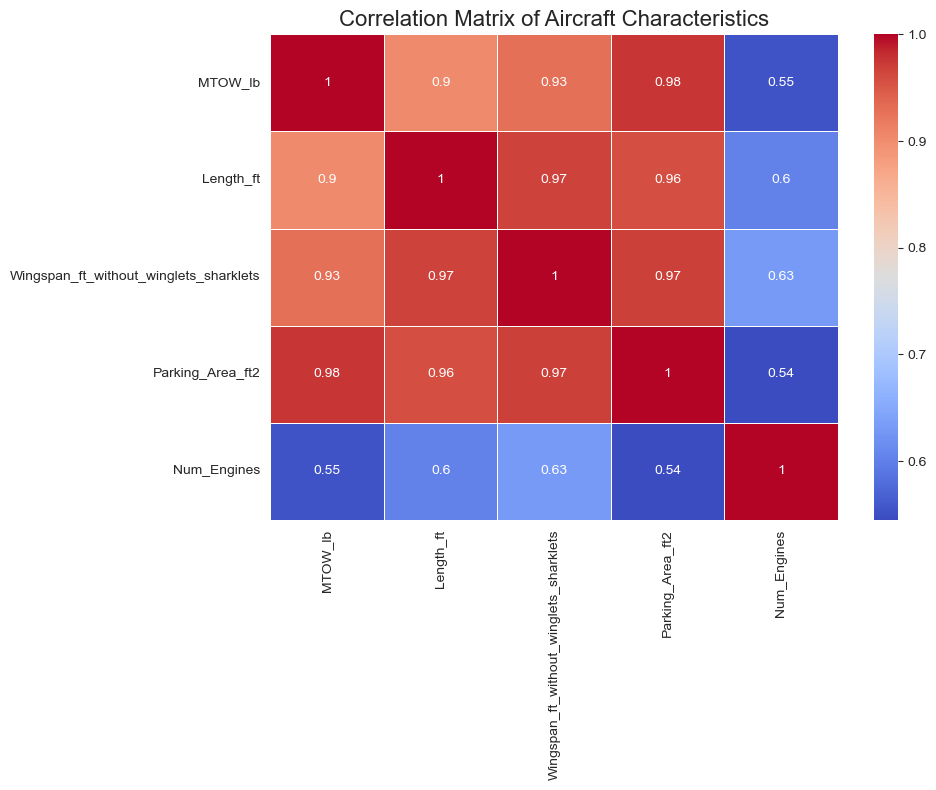

In [20]:
#correlation heatmap plot

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Aircraft Characteristics",
    fontsize=16
)

plt.tight_layout()



plt.savefig(
    os.path.expanduser(
        "~/Desktop/Airbus Orders and Deliveries Forecasting/Visuals/correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation of Aircraft Correlation Matrix

The correlation matrix demonstrates very strong positive relationships between the primary physical and operational characteristics of aircraft within the dataset.

### Key Findings

Maximum Take-Off Weight (MTOW) shows an extremely strong correlation with parking area requirements (0.98), indicating that heavier aircraft require substantially larger airport stand space and infrastructure support. Aircraft length and wingspan are also highly correlated (0.97), which is expected from an engineering perspective since larger aircraft are generally scaled proportionally across multiple dimensions. Wingspan exhibits a strong relationship with parking area (0.97), highlighting the operational importance of wing clearance and gate spacing in airport design. MTOW also correlates strongly with wingspan (0.93) and aircraft length (0.90), suggesting that increases in aircraft structural size are closely associated with increases in operational mass. The number of engines demonstrates only moderate correlations with the other variables (approximately 0.54–0.63). This suggests that aircraft size is not determined solely by engine count, as advances in engine efficiency allow modern twin-engine aircraft to achieve performance levels previously associated with larger multi-engine aircraft.

### Engineering and Operational Implications

The strong correlations confirm that airport infrastructure requirements scale closely with aircraft dimensions and weight characteristics.

- Larger aircraft impose significantly greater operational demands on:
  
  - gate allocation,
  - taxiway spacing,
  - runway design,
  - and parking stand capacity.

- The weaker relationship between engine count and aircraft size reflects modern aviation trends, particularly the dominance of efficient twin-engine long-haul aircraft such as the Airbus A350 and Boeing 787 families.

- These relationships are important for forecasting future airport congestion, infrastructure planning, and fleet modernisation strategies.

### Statistical Significance

1. Correlation coefficients above 0.90 indicate exceptionally strong linear relationships within the dataset.

2. The consistency of these relationships suggests that the cleaned dataset is highly suitable for further statistical modelling and predictive analysis.

3. The results also validate the reliability of the physical aircraft variables used throughout the analysis.

# Predictive Modelling
## Linear Regression Analysis

In [21]:
#variables for regression analysis

regression_data = aircraft_data[[
    "MTOW_lb",
    "Length_ft",
    "Wingspan_ft_without_winglets_sharklets",
    "Num_Engines",
    "Parking_Area_ft2"
]].dropna()

regression_data.head()

,MTOW_lb,Length_ft,Wingspan_ft_without_winglets_sharklets,Num_Engines,Parking_Area_ft2
0,50044.934,53.3,57.5,2,3935.3
1,892871.000,226.2,240.5,4,57915.6
5,363760.000,177.4,147.1,2,28666.7
6,363760.000,175.5,147.1,2,28352.9
7,317465.000,153.2,144.0,2,24361.0


In [22]:
#importing machine learning libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [23]:
#predictor variables (X) and target variable (y)

X = regression_data[[
    "Length_ft",
    "Wingspan_ft_without_winglets_sharklets",
    "Num_Engines",
    "Parking_Area_ft2"
]]

y = regression_data["MTOW_lb"]

In [24]:
#data splitting into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
#linear regression model

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [26]:
#predict MTOW values

y_pred = model.predict(X_test)

In [27]:
#evaluate regression model performance

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")

print(f"Root Mean Squared Error: {rmse:.2f}")

print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 21863.66
Root Mean Squared Error: 32141.32
R² Score: 0.9760


## Interpretation of Linear Regression Model

The linear regression model produced a very strong predictive performance when estimating Maximum Take-Off Weight (MTOW) using aircraft physical characteristics.

### Model Performance Metrics

- Mean Absolute Error (MAE): approximately 21,864 lb
- Root Mean Squared Error (RMSE): approximately 32,141 lb
- R² Score: 0.976

### Key Findings

- The R² value of 0.976 indicates that approximately 97.6% of the variation in aircraft MTOW is explained by the selected predictor variables.

- This demonstrates an exceptionally strong linear relationship between aircraft dimensions and operational weight characteristics.

- Aircraft length, wingspan, parking area, and engine count collectively provide a highly accurate estimate of aircraft mass.

- The relatively low prediction error compared to the scale of commercial aircraft weights suggests that the model captures the underlying engineering relationships effectively.

### Engineering Interpretation

- Larger aircraft naturally require:
  - greater structural mass,
  - larger wingspans,
  - increased parking space,
  - and more operational infrastructure.

- The results confirm that aircraft geometry and airport operational requirements scale consistently with aircraft weight.

- The strong predictive capability also reflects the standardised engineering principles used in modern aircraft design.

### Statistical Significance

- An R² score above 0.95 is generally considered extremely strong for real-world engineering datasets.

- The model demonstrates that aircraft physical dimensions can serve as highly reliable predictors of operational performance characteristics.

- These findings suggest that future predictive models could be expanded to forecast:
  - airport gate requirements,
  - runway usage,
  - fuel efficiency,
  - or congestion impacts.

### Limitations

- Although the model performs strongly, it assumes linear relationships between variables.

- Certain aircraft categories, such as military aircraft or specialised cargo aircraft, may behave differently from standard commercial aircraft.

- Additional variables such as fuel capacity, passenger load, and propulsion technology could improve predictive accuracy further.

# Residual Analysis
## Evaluating Prediction Errors

In [29]:
#calculate residuals

residuals = y_test - y_pred

residuals.head()

170    -5723.145214
38    -22581.013290
18    -55471.252955
331     2994.620231
62    -27760.093657
Name: MTOW_lb, dtype: float64

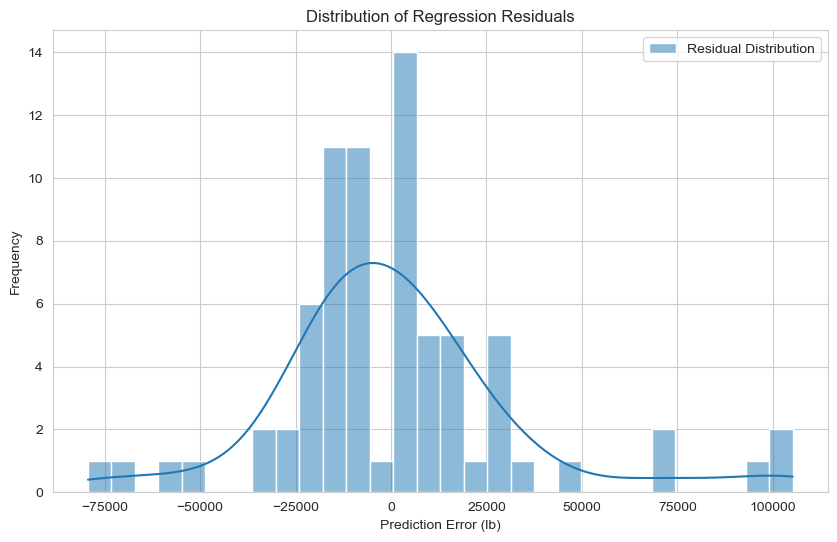

In [32]:
#residual distribution plot

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    label="Residual Distribution"
)

plt.title("Distribution of Regression Residuals")

plt.xlabel("Prediction Error (lb)")

plt.ylabel("Frequency")

plt.legend()

plt.savefig(
    os.path.expanduser(
        "~/Desktop/Airbus Orders and Deliveries Forecasting/Visuals/residual_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation of Regression Residual Distribution

### Distribution of Regression Residuals

- The residual distribution plot illustrates the prediction errors of the regression model, calculated as:

  \[
  \text{Residual} = \text{Actual MTOW} - \text{Predicted MTOW}
  \]

- Residuals are centred close to zero, indicating that the model is generally unbiased and does not systematically overpredict or underpredict aircraft weight.

- The approximately bell-shaped distribution suggests that the regression errors follow a near-normal distribution, which is a desirable characteristic in linear regression modelling.

- Most prediction errors fall within a relatively narrow range around zero, demonstrating good model consistency and stability.

- Some larger residuals appear on both the positive and negative sides of the distribution, representing aircraft where predictions were less accurate.

- These outliers are likely associated with unusually large aircraft, specialised aircraft categories, or designs with characteristics not fully captured by the selected predictor variables.

- The absence of severe skewness indicates that prediction errors remain balanced across the dataset.

- Combined with the low Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), the residual analysis confirms that the regression model performs strongly overall.

- The residual plot therefore supports the conclusion that the linear regression model is statistically reliable for predicting aircraft MTOW using aircraft dimensional characteristics.

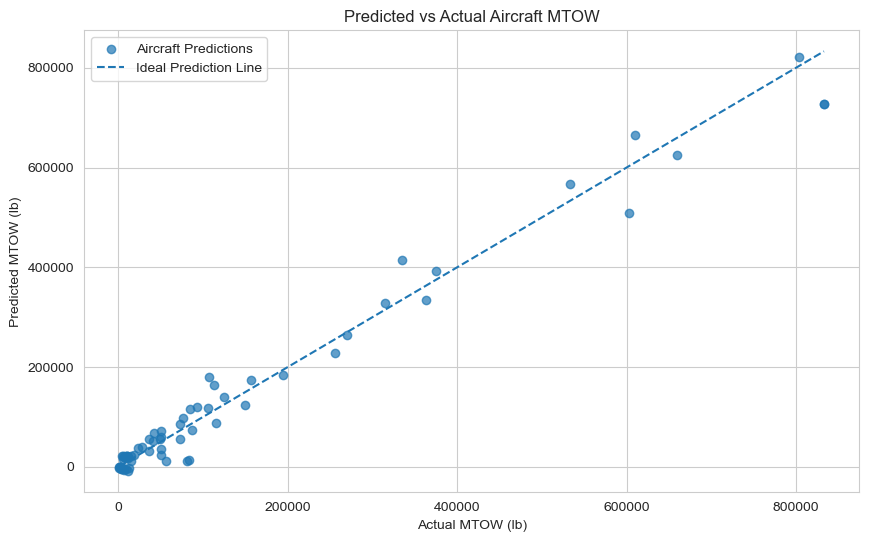

In [35]:
#Comparison of predicted vs actual MTOW (maximum take-off weight) values


plt.figure(figsize=(10, 6))

#model predictions (scatter)
plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    label="Aircraft Predictions"
)

#ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Ideal Prediction Line"
)

plt.xlabel("Actual MTOW (lb)")
plt.ylabel("Predicted MTOW (lb)")
plt.title("Predicted vs Actual Aircraft MTOW")

plt.legend()


plt.savefig(
    os.path.expanduser(
        "~/Desktop/Airbus Orders and Deliveries Forecasting/Visuals/Actual vs Predicted MTOW.png"
    ),
    dpi=300,
    bbox_inches="tight"
)



plt.show()

## Interpretation of Regression Model Results

### Predicted vs Actual Aircraft MTOW

- The scatter plot compares the predicted Maximum Takeoff Weight (MTOW) values generated by the regression model against the actual MTOW values from the dataset.

- The dashed diagonal line represents an ideal prediction scenario where predicted values exactly match the actual values.

- Most data points lie very close to the ideal prediction line, indicating that the regression model performs extremely well in estimating aircraft MTOW.

- The clustering of points around the line demonstrates a strong linear relationship between the predictor variables and aircraft weight.

- Smaller aircraft are densely concentrated near the lower-left region of the graph, reflecting the higher number of light aircraft within the dataset.

- As aircraft size increases, prediction errors become slightly larger. This is expected because larger commercial aircraft typically exhibit greater structural and operational complexity.

- A few heavier aircraft deviate moderately from the ideal line, suggesting that the model slightly underestimates or overestimates some large aircraft weights.

- Despite these deviations, the overall spread remains relatively tight, supporting the high R² score obtained earlier (0.976), meaning the model explains approximately 97.6% of the variance in MTOW.

- The model therefore demonstrates strong predictive capability and captures the underlying engineering relationships between aircraft dimensions and weight characteristics effectively.

# Advanced Statistical Analysis

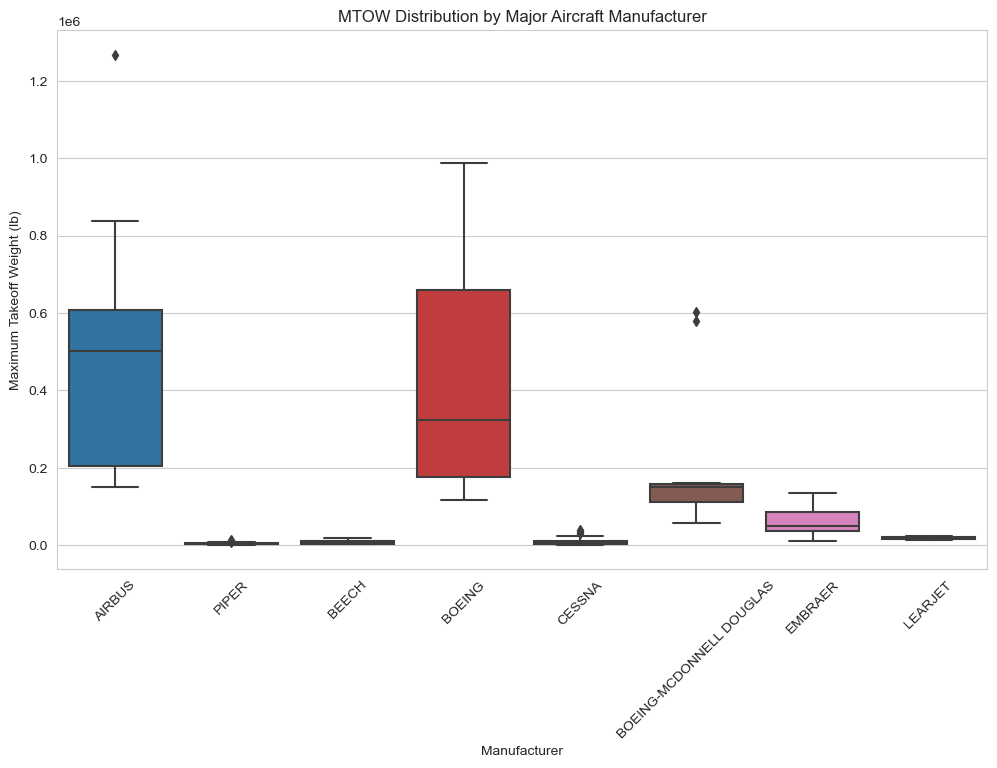

In [36]:
#box plot

top_manufacturers = aircraft_data["Manufacturer"].value_counts().nlargest(8).index

filtered_data = aircraft_data[
    aircraft_data["Manufacturer"].isin(top_manufacturers)
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=filtered_data,
    x="Manufacturer",
    y="MTOW_lb"
)

plt.xticks(rotation=45)

plt.title("MTOW Distribution by Major Aircraft Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Maximum Takeoff Weight (lb)")

plt.savefig(
    os.path.expanduser(
        "~/Desktop/Airbus Orders and Deliveries Forecasting/Visuals/MTOW Distribution by Major Aircraft Manufacturer.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
from scipy.stats import ttest_ind

boeing_mtow = aircraft_data[
    aircraft_data["Manufacturer"] == "BOEING"
]["MTOW_lb"]

airbus_mtow = aircraft_data[
    aircraft_data["Manufacturer"] == "AIRBUS"
]["MTOW_lb"]

t_stat, p_value = ttest_ind(
    boeing_mtow,
    airbus_mtow,
    equal_var=False
)

print("T-Statistic:", round(t_stat, 3))
print("P-Value:", p_value)

T-Statistic: -0.602
P-Value: 0.5504267296170138


## Statistical Comparison Between Boeing and Airbus MTOW

A two-sample independent t-test was conducted to determine whether there is a statistically significant difference between the Maximum Takeoff Weight (MTOW) distributions of Boeing and Airbus aircraft within the dataset.

### Results

- T-Statistic: -0.602
- P-Value: 0.550

### Interpretation

- The p-value obtained from the statistical test is significantly greater than the standard significance threshold of 0.05.

- Therefore, the null hypothesis cannot be rejected.

- This indicates that there is no statistically significant difference between the MTOW distributions of Boeing and Airbus aircraft in this dataset.

- Although Boeing and Airbus manufacture aircraft for different operational markets, both companies produce a broad range of aircraft types spanning narrow-body, wide-body, and long-haul categories, which may explain the similarity in weight distributions.

- The relatively small t-statistic further supports the conclusion that the mean MTOW values between the two manufacturers are closely aligned.

- From an aviation engineering perspective, this result suggests that aircraft size and operational role may influence MTOW more strongly than manufacturer identity alone.

- This analysis demonstrates the usefulness of inferential statistics in evaluating whether observed differences within aviation datasets are genuinely meaningful or simply due to random variation.

# Current Project Status

Currently:

- Data cleaning and preprocessing
- Exploratory data analysis of aircraft characteristics
- Manufacturer distribution analysis
- Correlation analysis of aircraft dimensions and weight
- Linear regression modelling for MTOW prediction
- Regression evaluation metrics
- Residual diagnostics
- Statistical hypothesis testing between Boeing and Airbus MTOW distributions

Later on:
- Classification modelling
- Feature importance analysis
- Time-series forecasting of aircraft deliveries
- Advanced aviation operational analytics